# Categorical plot hands-on
<img src="https://s3.amazonaws.com/assets.liffafi.com/wp-content/uploads/2025/10/24003625/marve-1.webp">

In this hands-on, we will use the Marvel dataset to practice using different plots to visualize distributions of values between groups. You are free to come up with you own questions and use one of the categorical plots to help answer each question. You are also free to build your own dataframe that contains a specific subset of the data to help you answer your questions.

The dataset is in https://raw.githubusercontent.com/csbfx/advpy122-data/master/marvel-wikia-data.csv

Data source: https://github.com/fivethirtyeight/data/tree/master/comic-characters

| Variable |	Definition |
| :------- | :-
|page_id|	The unique identifier for that characters page within the wikia
|name|	The name of the character
|urlslug|	The unique url within the wikia that takes you to the character
|ID|	The identity status of the character (Secret Identity, Public identity, [on marvel only: No Dual Identity])
|ALIGN|	If the character is Good, Bad or Neutral
|EYE|	Eye color of the character
|HAIR|	Hair color of the character
|SEX|	Sex of the character (e.g. Male, Female, etc.)
|GSM|	If the character is a gender or sexual minority (e.g. Homosexual characters, bisexual characters)
|ALIVE|	If the character is alive or deceased
|APPEARANCES|	The number of appareances of the character in comic books (as of Sep. 2, 2014. Number will become increasingly out of date as time goes on.)
|FIRST APPEARANCE|	The month and year of the character's first appearance in a comic book, if available
|YEAR|	The year of the character's first appearance in a comic book, if available

## Q1. How big is this dataset?
Use pandas to find out the number of rows and columns.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

marvel_url = 'https://raw.githubusercontent.com/csbfx/advpy122-data/master/marvel-wikia-data.csv'
marvel = pd.read_csv(marvel_url)
print(f'The dataset contains {marvel.shape[0]:,} rows and {marvel.shape[1]} columns.')
display(marvel.head())


The dataset contains 16,376 rows and 13 columns.


,page_id,name,urlslug,ID,ALIGN,EYE,HAIR,SEX,GSM,ALIVE,APPEARANCES,FIRST APPEARANCE,Year
0,1678,Spider-Man (Peter Parker),\/Spider-Man_(Peter_Parker),Secret Identity,Good Characters,Hazel Eyes,Brown Hair,Male Characters,NaN,Living Characters,4043.0,Aug-62,1962.0
1,7139,Captain America (Steven Rogers),\/Captain_America_(Steven_Rogers),Public Identity,Good Characters,Blue Eyes,White Hair,Male Characters,NaN,Living Characters,3360.0,Mar-41,1941.0
2,64786,"Wolverine (James \""Logan\"" Howlett)",\/Wolverine_(James_%22Logan%22_Howlett),Public Identity,Neutral Characters,Blue Eyes,Black Hair,Male Characters,NaN,Living Characters,3061.0,Oct-74,1974.0
3,1868,"Iron Man (Anthony \""Tony\"" Stark)",\/Iron_Man_(Anthony_%22Tony%22_Stark),Public Identity,Good Characters,Blue Eyes,Black Hair,Male Characters,NaN,Living Characters,2961.0,Mar-63,1963.0
4,2460,Thor (Thor Odinson),\/Thor_(Thor_Odinson),No Dual Identity,Good Characters,Blue Eyes,Blond Hair,Male Characters,NaN,Living Characters,2258.0,Nov-50,1950.0


## Q2. Strip plots
Come up with a question using this dataset and use a `strip` plot to help answer the question. State your question in a markdown cell. Recall that a `strip` plot is a categorical plot where one axis is category and the other is a continuous variable. Set the appropriate arguments to make the plot more readable. Be sure to include a meaning title for the plot.

**Question:** How do positive recorded comic-appearance counts differ among good, bad, and neutral characters?


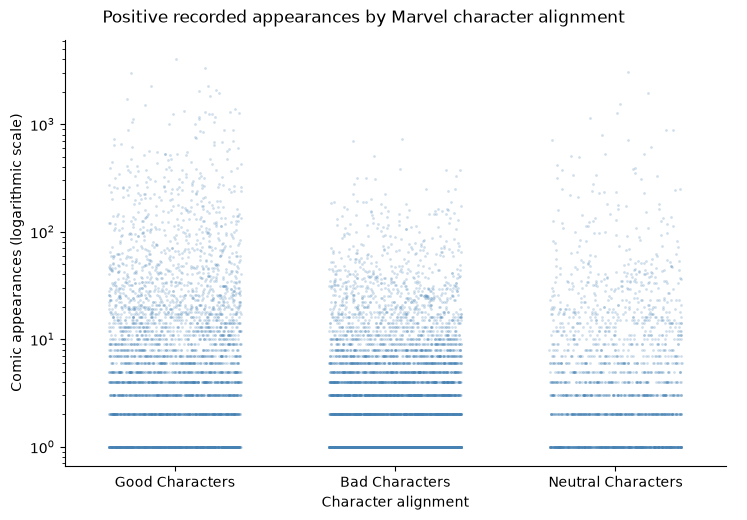

In [2]:
alignment_order = ['Good Characters', 'Bad Characters', 'Neutral Characters']
appearances = marvel.loc[
    marvel['ALIGN'].isin(alignment_order) & (marvel['APPEARANCES'] > 0)
].copy()
g = sns.catplot(data=appearances, x='ALIGN', y='APPEARANCES', kind='strip',
                order=alignment_order, jitter=0.3, alpha=0.25, size=2,
                color='steelblue', height=5, aspect=1.5)
g.set(yscale='log')
g.set_axis_labels('Character alignment', 'Comic appearances (logarithmic scale)')
g.fig.suptitle('Positive recorded appearances by Marvel character alignment', y=1.03)
plt.show()


## Q3. Multiples of Strip plots
Come up with a question using this dataset and use a strip plot that contains multiples (splitting the plot into multiples by a category that has two or more unique values) by using the `row` or `col` argument. State your question in a markdown cell. Recall that a strip plot is a categorical plot where one axis is category and the other is a continuous variable. Set the appropriate arguments to make the plot more readable. Be sure to include a meaning title for the plot.

**Question:** Does the distribution of appearances by alignment differ between living and deceased characters in this dataset?


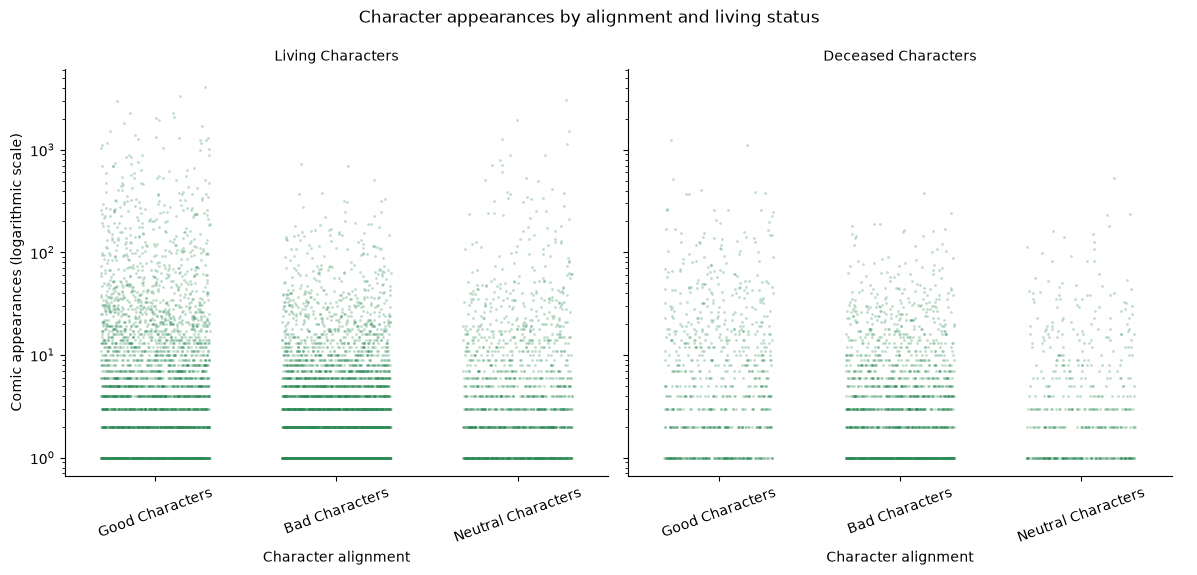

In [3]:
alive_order = ['Living Characters', 'Deceased Characters']
appearances_by_status = appearances.loc[appearances['ALIVE'].isin(alive_order)]
g = sns.catplot(data=appearances_by_status, x='ALIGN', y='APPEARANCES',
                col='ALIVE', col_order=alive_order, kind='strip',
                order=alignment_order, jitter=0.3, alpha=0.3, size=2,
                color='seagreen', height=5, aspect=1.2)
g.set(yscale='log')
g.set_axis_labels('Character alignment', 'Comic appearances (logarithmic scale)')
g.set_titles('{col_name}')
g.set_xticklabels(rotation=20)
g.fig.suptitle('Character appearances by alignment and living status', y=1.05)
plt.show()


## Q4. Swarm plot
Come up with a question using this dataset and use a `swarm` plot to help answer the question. State your question in a markdown cell. Recall that a `swarm` plot is also a categorical plot where one axis is category and the other is a continuous variable. Set the appropriate arguments to make the plot more readable. Be sure to include a meaning title for the plot.

**Question:** In a reproducible sample of 180 characters, how do debut years differ among good, bad, and neutral characters?

The sample keeps the swarm readable. The following boxplot uses the same sample so the two views are directly comparable.


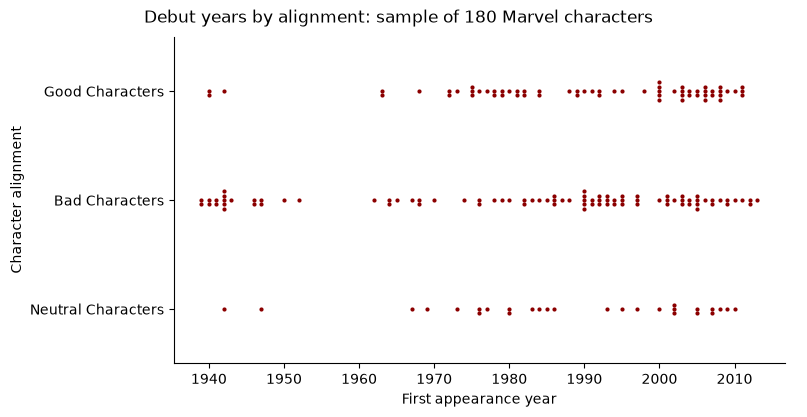

In [4]:
debut_data = marvel.loc[marvel['ALIGN'].isin(alignment_order)].dropna(subset=['Year'])
debut_sample = debut_data.sample(n=min(180, len(debut_data)), random_state=1)
g = sns.catplot(data=debut_sample, x='Year', y='ALIGN', kind='swarm',
                order=alignment_order, size=3, color='darkred', height=4, aspect=2)
g.set_axis_labels('First appearance year', 'Character alignment')
g.fig.suptitle('Debut years by alignment: sample of 180 Marvel characters', y=1.03)
plt.show()


## Q5. Box plots
Box plot is one of the most commonly used plot for visualizing data distribution. We can convert the `swamp` plot into a `box` plot by simply changing the kind argument to `kind="box"`. Convert the swarm plot that you created in Q4 with a boxplot here. Set the appropriate arguments to make the plot more readable. Be sure to include a meaning title for the plot.

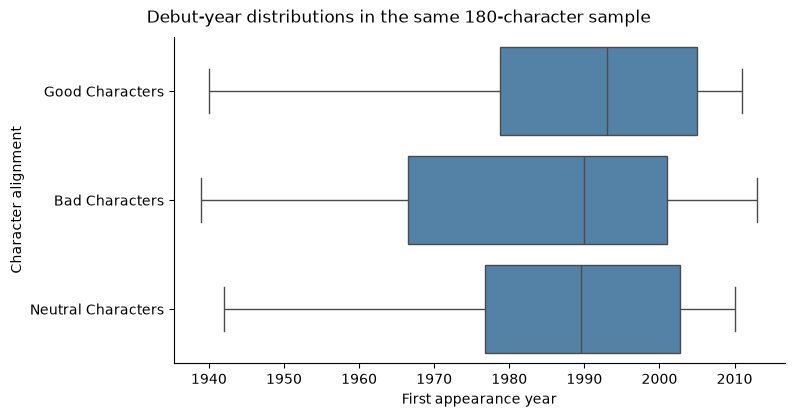

In [5]:
g = sns.catplot(data=debut_sample, x='Year', y='ALIGN', kind='box',
                order=alignment_order, color='steelblue', height=4, aspect=2)
g.set_axis_labels('First appearance year', 'Character alignment')
g.fig.suptitle('Debut-year distributions in the same 180-character sample', y=1.03)
plt.show()


## Q6. Violin plots
Come up with a question using this dataset and use a `violin` plot to help answer the question. State your question in a markdown cell. Recall that a `violin` plot is also a categorical plot where one axis is category and the other is a continuous variable. Set the appropriate arguments to make the plot more readable. You might want to set setting `cut` to zero if the distribution spreads beyond the values of the data in the dataset. Be sure to include a meaning title for the plot.

**Question:** How does the distribution of debut years compare across character alignments in all records with known debut years?


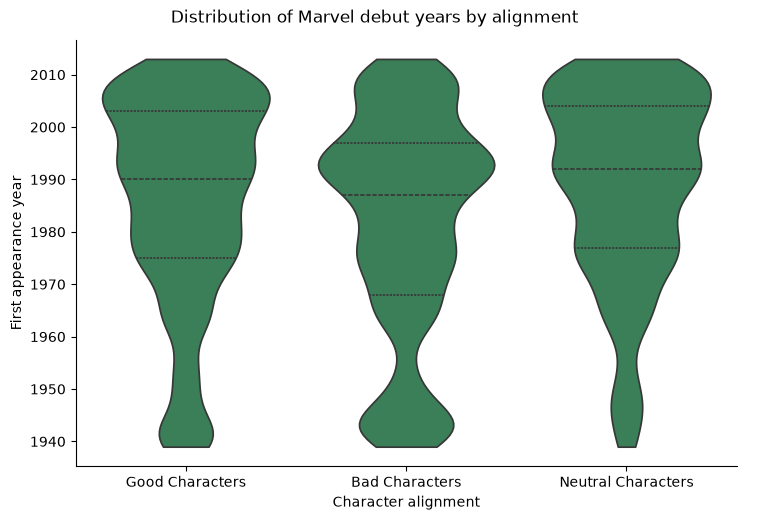

In [6]:
g = sns.catplot(data=debut_data, x='ALIGN', y='Year', kind='violin',
                order=alignment_order, cut=0, inner='quartile', color='seagreen',
                height=5, aspect=1.5)
g.set_axis_labels('Character alignment', 'First appearance year')
g.fig.suptitle('Distribution of Marvel debut years by alignment', y=1.03)
plt.show()


## Bonus:
Because violin plots are symetrical, when we have only two categories we can put one on each side with `split = True`. Try to create a violin plot using the `split` parameter. You will need to come up with a dataframe using this dataset with data that has two categories.

**Question:** Within each alignment, do living and deceased characters have different distributions of debut years?


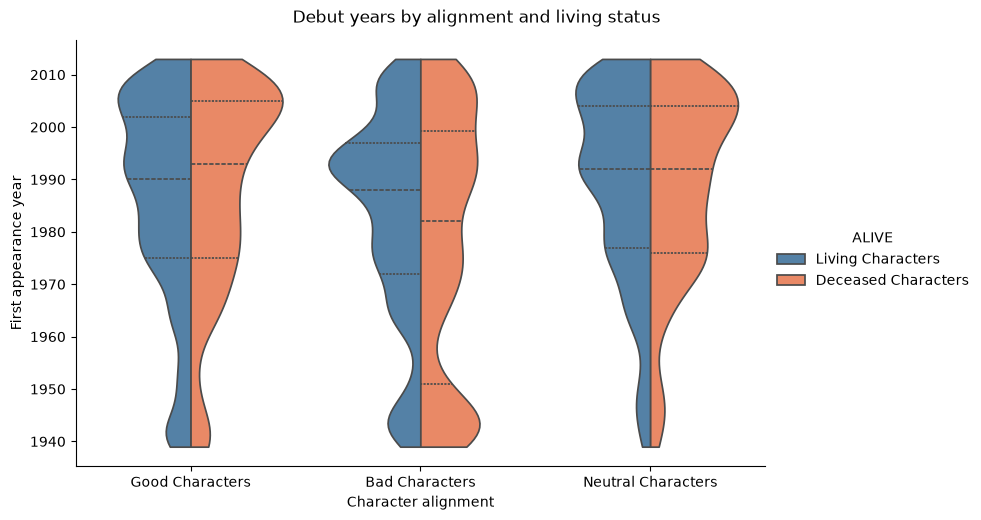

In [7]:
split_debuts = debut_data.loc[debut_data['ALIVE'].isin(alive_order)]
g = sns.catplot(data=split_debuts, x='ALIGN', y='Year', hue='ALIVE',
                order=alignment_order, hue_order=alive_order, kind='violin',
                split=True, cut=0, inner='quartile',
                palette=['steelblue', 'coral'], height=5, aspect=1.6)
g.set_axis_labels('Character alignment', 'First appearance year')
g.fig.suptitle('Debut years by alignment and living status', y=1.03)
plt.show()
